### Basic exploratory data analysis

##  Setup & Data Loading

In [85]:
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve repo root regardless of where the kernel was launched
# (works whether cwd is the repo root or notebooks/).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())

# Single source of truth for paths
with (ROOT / "config" / "config.yaml").open() as f:
    cfg = yaml.safe_load(f)

# Styling
sns.set_theme(style="whitegrid")
%matplotlib inline

# EDA on TRAIN ONLY — val/test stay held out
train_df = pd.read_parquet(ROOT / cfg["data_paths"]["train"])

print(f"Dataset Shape: {train_df.shape}")
print(f"Date range:    {train_df['stay_date'].min().date()} → {train_df['stay_date'].max().date()}")
train_df.head()


Dataset Shape: (145800, 45)
Date range:    2024-01-01 → 2025-04-30


,property_id,region,country,quality_tier,host_pricing_style,property_type,bedrooms,bathrooms,capacity,wifi,...,host_price_shock,date_base_price,discount_pct,shown_price,beta_base,beta_discount,expected_booking_prob,booking_bool,expected_cancel_prob,cancelled_bool
0,P0000,Andalusia,Spain,mid,static,apartment,4,2,8,1,...,1.015236,227.903190,0.10,205.112871,-1.2,1.8,0.276031,0,0.154274,0
1,P0000,Andalusia,Spain,mid,static,apartment,4,2,8,1,...,0.948001,212.810062,0.10,191.529056,-1.2,1.8,0.265714,0,0.152938,0
2,P0000,Andalusia,Spain,mid,static,apartment,4,2,8,1,...,1.037523,232.906177,0.10,209.615559,-1.2,1.8,0.279747,0,0.154699,0
3,P0000,Andalusia,Spain,mid,static,apartment,4,2,8,1,...,1.047028,235.040039,0.00,235.040039,-1.2,1.8,0.246447,0,0.156958,0
4,P0000,Andalusia,Spain,mid,static,apartment,4,2,8,1,...,0.902448,232.971932,0.15,198.026142,-1.2,1.8,0.348372,0,0.153587,0


## Data Sanity Checks

In [86]:
# Before EDA, some of the columns in the df, will have to be eliminated as they were created during DGP and are not needed for analysis.

# DGP truth — never feed to a model                                                                                                                                     
LEAK_COLS = ["expected_booking_prob", "expected_cancel_prob",                                                                                                           
            "beta_base", "beta_discount"]
IDENT_NOISE_COLS = ["host_price_shock"]                                                                                                                                                                          
# Synthetic-only artifacts (no real-world analog — host doesn't set these as separate fields)                                                                           
ARTIFACT_COLS = ["base_price", "seasonal_mult", "weekend_mult"]
                                                                                                                                                                                      
                                                                                                                                                                        
# Redundant with already-included calendar features
REDUNDANT_COLS = ["seasonal_mult", "weekend_mult"]                                                                                                                                                                   
       
train_df = train_df.drop(columns=LEAK_COLS + IDENT_NOISE_COLS + ARTIFACT_COLS,errors="ignore")

In [87]:
# Quick profile — schema, missingness, numeric summary, categorical balance.
# Targeted alternative to a full auto-profiler: tied to the variables that matter
# for this DGP rather than a generic 100-page report.


print("=== dtypes & non-null counts ===")
train_df.info()

print("\n=== missing values per column ===")
missing = train_df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False) if missing.any() else "no missing values")

print("\n=== numeric summary (key pricing + outcome columns) ===")
num_view = [ "shown_price", "discount_pct", "lead_time", "los",
            "rating", "review_count", "bedrooms",
             "booking_bool",
             "cancelled_bool"]
display(train_df[num_view].describe().T.round(3))

print("\n=== categorical balance ===")
for col in ["region", "country", "quality_tier", "host_pricing_style",
            "property_type", "view", "cancel_policy"]:
    print(f"\n{col}")
    print(train_df[col].value_counts(normalize=True).round(3))





=== dtypes & non-null counts ===
<class 'pandas.DataFrame'>
Index: 145800 entries, 0 to 437324
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   property_id             145800 non-null  str           
 1   region                  145800 non-null  str           
 2   country                 145800 non-null  str           
 3   quality_tier            145800 non-null  str           
 4   host_pricing_style      145800 non-null  str           
 5   property_type           145800 non-null  str           
 6   bedrooms                145800 non-null  int64         
 7   bathrooms               145800 non-null  int64         
 8   capacity                145800 non-null  int64         
 9   wifi                    145800 non-null  int64         
 10  pool                    145800 non-null  int64         
 11  parking                 145800 non-null  int64         
 12  ac           

,count,mean,std,min,25%,50%,75%,max
shown_price,145800.0,212.510,173.424,20.739,85.341,155.508,283.687,1265.208
discount_pct,145800.0,0.061,0.078,0.000,0.000,0.000,0.100,0.300
lead_time,145800.0,29.200,29.366,0.000,8.000,20.000,41.000,180.000
los,145800.0,3.937,2.230,1.000,2.000,3.000,6.000,8.000
rating,145800.0,4.120,0.438,2.900,3.800,4.150,4.425,5.000
review_count,145800.0,41.287,35.502,3.000,19.750,32.000,51.000,332.000
bedrooms,145800.0,2.307,1.521,1.000,1.000,2.000,3.000,8.000
booking_bool,145800.0,0.286,0.452,0.000,0.000,0.000,1.000,1.000
cancelled_bool,145800.0,0.067,0.251,0.000,0.000,0.000,0.000,1.000



=== categorical balance ===

region
region
Brittany     0.240
Catalonia    0.207
Andalusia    0.193
Tuscany      0.190
Provence     0.170
Name: proportion, dtype: float64

country
country
France    0.41
Spain     0.40
Italy     0.19
Name: proportion, dtype: float64

quality_tier
quality_tier
mid        0.427
budget     0.383
premium    0.190
Name: proportion, dtype: float64

host_pricing_style
host_pricing_style
static     0.5
dynamic    0.3
premium    0.2
Name: proportion, dtype: float64

property_type
property_type
apartment    0.337
house        0.190
studio       0.173
cottage      0.147
villa        0.090
cabin        0.063
Name: proportion, dtype: float64

view
view
none        0.297
garden      0.253
sea         0.167
mountain    0.150
city        0.133
Name: proportion, dtype: float64

cancel_policy
cancel_policy
moderate    0.450
flexible    0.287
strict      0.263
Name: proportion, dtype: float64


In [88]:
# Identify variable types
cat_cols = ['region', 'quality_tier', 'property_type', 'view', 'cancel_policy']
num_cols = [ 'shown_price', 'discount_pct', 'rating', 'review_count', 'bedrooms']
outcome_cols = ['booking_bool', 'cancelled_bool']

# Descriptive stats for pricing by quality tier
train_df.groupby('quality_tier')[[ 'shown_price']].describe()

shown_price                                                  \
                   count        mean         std         min         25%   
quality_tier                                                               
budget           55890.0   83.598271   42.472605   20.739136   54.135395   
mid              62208.0  205.301350   89.370424   50.961144  140.866181   
premium          27702.0  488.784075  163.547065  176.016649  366.136347   

                                                   
                     50%         75%          max  
quality_tier                                       
budget         73.566870  101.295151   399.286013  
mid           187.140294  249.387414   852.658473  
premium       460.616715  581.921492  1265.208067

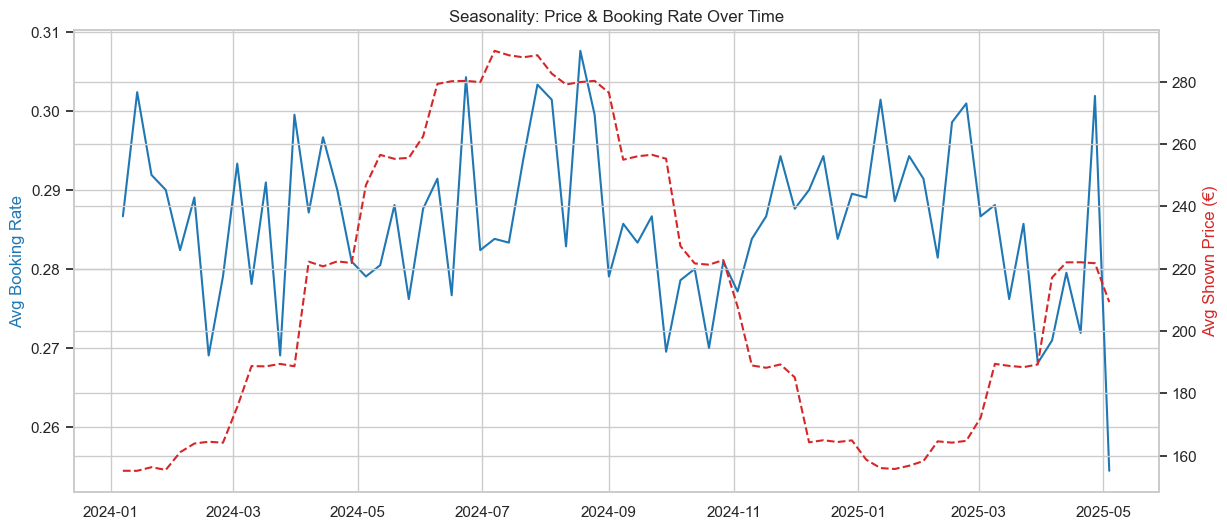

In [89]:
# Time-series of Bookings and Prices
resampled = train_df.set_index('stay_date').resample('W').agg({
    'booking_bool': 'mean',
    'shown_price': 'mean'
})

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_title("Seasonality: Price & Booking Rate Over Time")
ax1.plot(resampled.index, resampled['booking_bool'], color='tab:blue', label='Booking Rate')
ax1.set_ylabel('Avg Booking Rate', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(resampled.index, resampled['shown_price'], color='tab:red', label='Avg Shown Price', linestyle='--')
ax2.set_ylabel('Avg Shown Price (€)', color='tab:red')

plt.show()

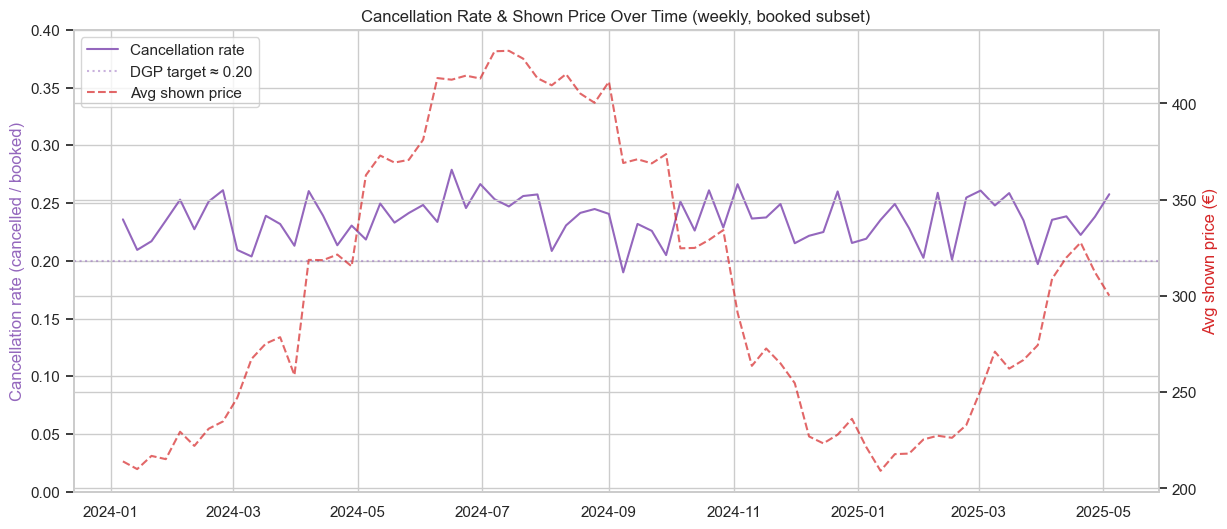

Aggregate cancellation rate (conditional on booked): 0.236   (target ≈ 0.20)
Weekly bookings (min / median / max): 229 / 602 / 646


In [90]:
# Cancellation rate over time — conditional on booking.
# Phase 2 sanity:
#   - aggregate conditional rate should land near ~20% (DGP design)
#   - any temporal trend should mildly track shown_price (β_cancel ≈ +0.15 → buyer's remorse)
#   - low-volume weeks → noisy rate; print sample-size summary so we don't over-interpret spikes

booked = train_df[train_df["booking_bool"] == 1]

resampled_cancel = booked.set_index("stay_date").resample("W").agg(
    cancel_rate=("cancelled_bool", "mean"),
    avg_shown_price=("shown_price", "mean"),
    n_bookings=("booking_bool", "size"),
)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.set_title("Cancellation Rate & Shown Price Over Time (weekly, booked subset)")
ax1.plot(resampled_cancel.index, resampled_cancel["cancel_rate"],
         color="tab:purple", label="Cancellation rate")
ax1.axhline(0.20, color="tab:purple", linestyle=":", alpha=0.5,
            label="DGP target ≈ 0.20")
ax1.set_ylabel("Cancellation rate (cancelled / booked)", color="tab:purple")
ax1.set_ylim(0, max(0.4, resampled_cancel["cancel_rate"].max() * 1.15))

ax2 = ax1.twinx()
ax2.plot(resampled_cancel.index, resampled_cancel["avg_shown_price"],
         color="tab:red", linestyle="--", alpha=0.7, label="Avg shown price")
ax2.set_ylabel("Avg shown price (€)", color="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.show()

print(f"Aggregate cancellation rate (conditional on booked): "
      f"{booked['cancelled_bool'].mean():.3f}   (target ≈ 0.20)")
print(f"Weekly bookings (min / median / max): "
      f"{resampled_cancel['n_bookings'].min():.0f} / "
      f"{resampled_cancel['n_bookings'].median():.0f} / "
      f"{resampled_cancel['n_bookings'].max():.0f}")


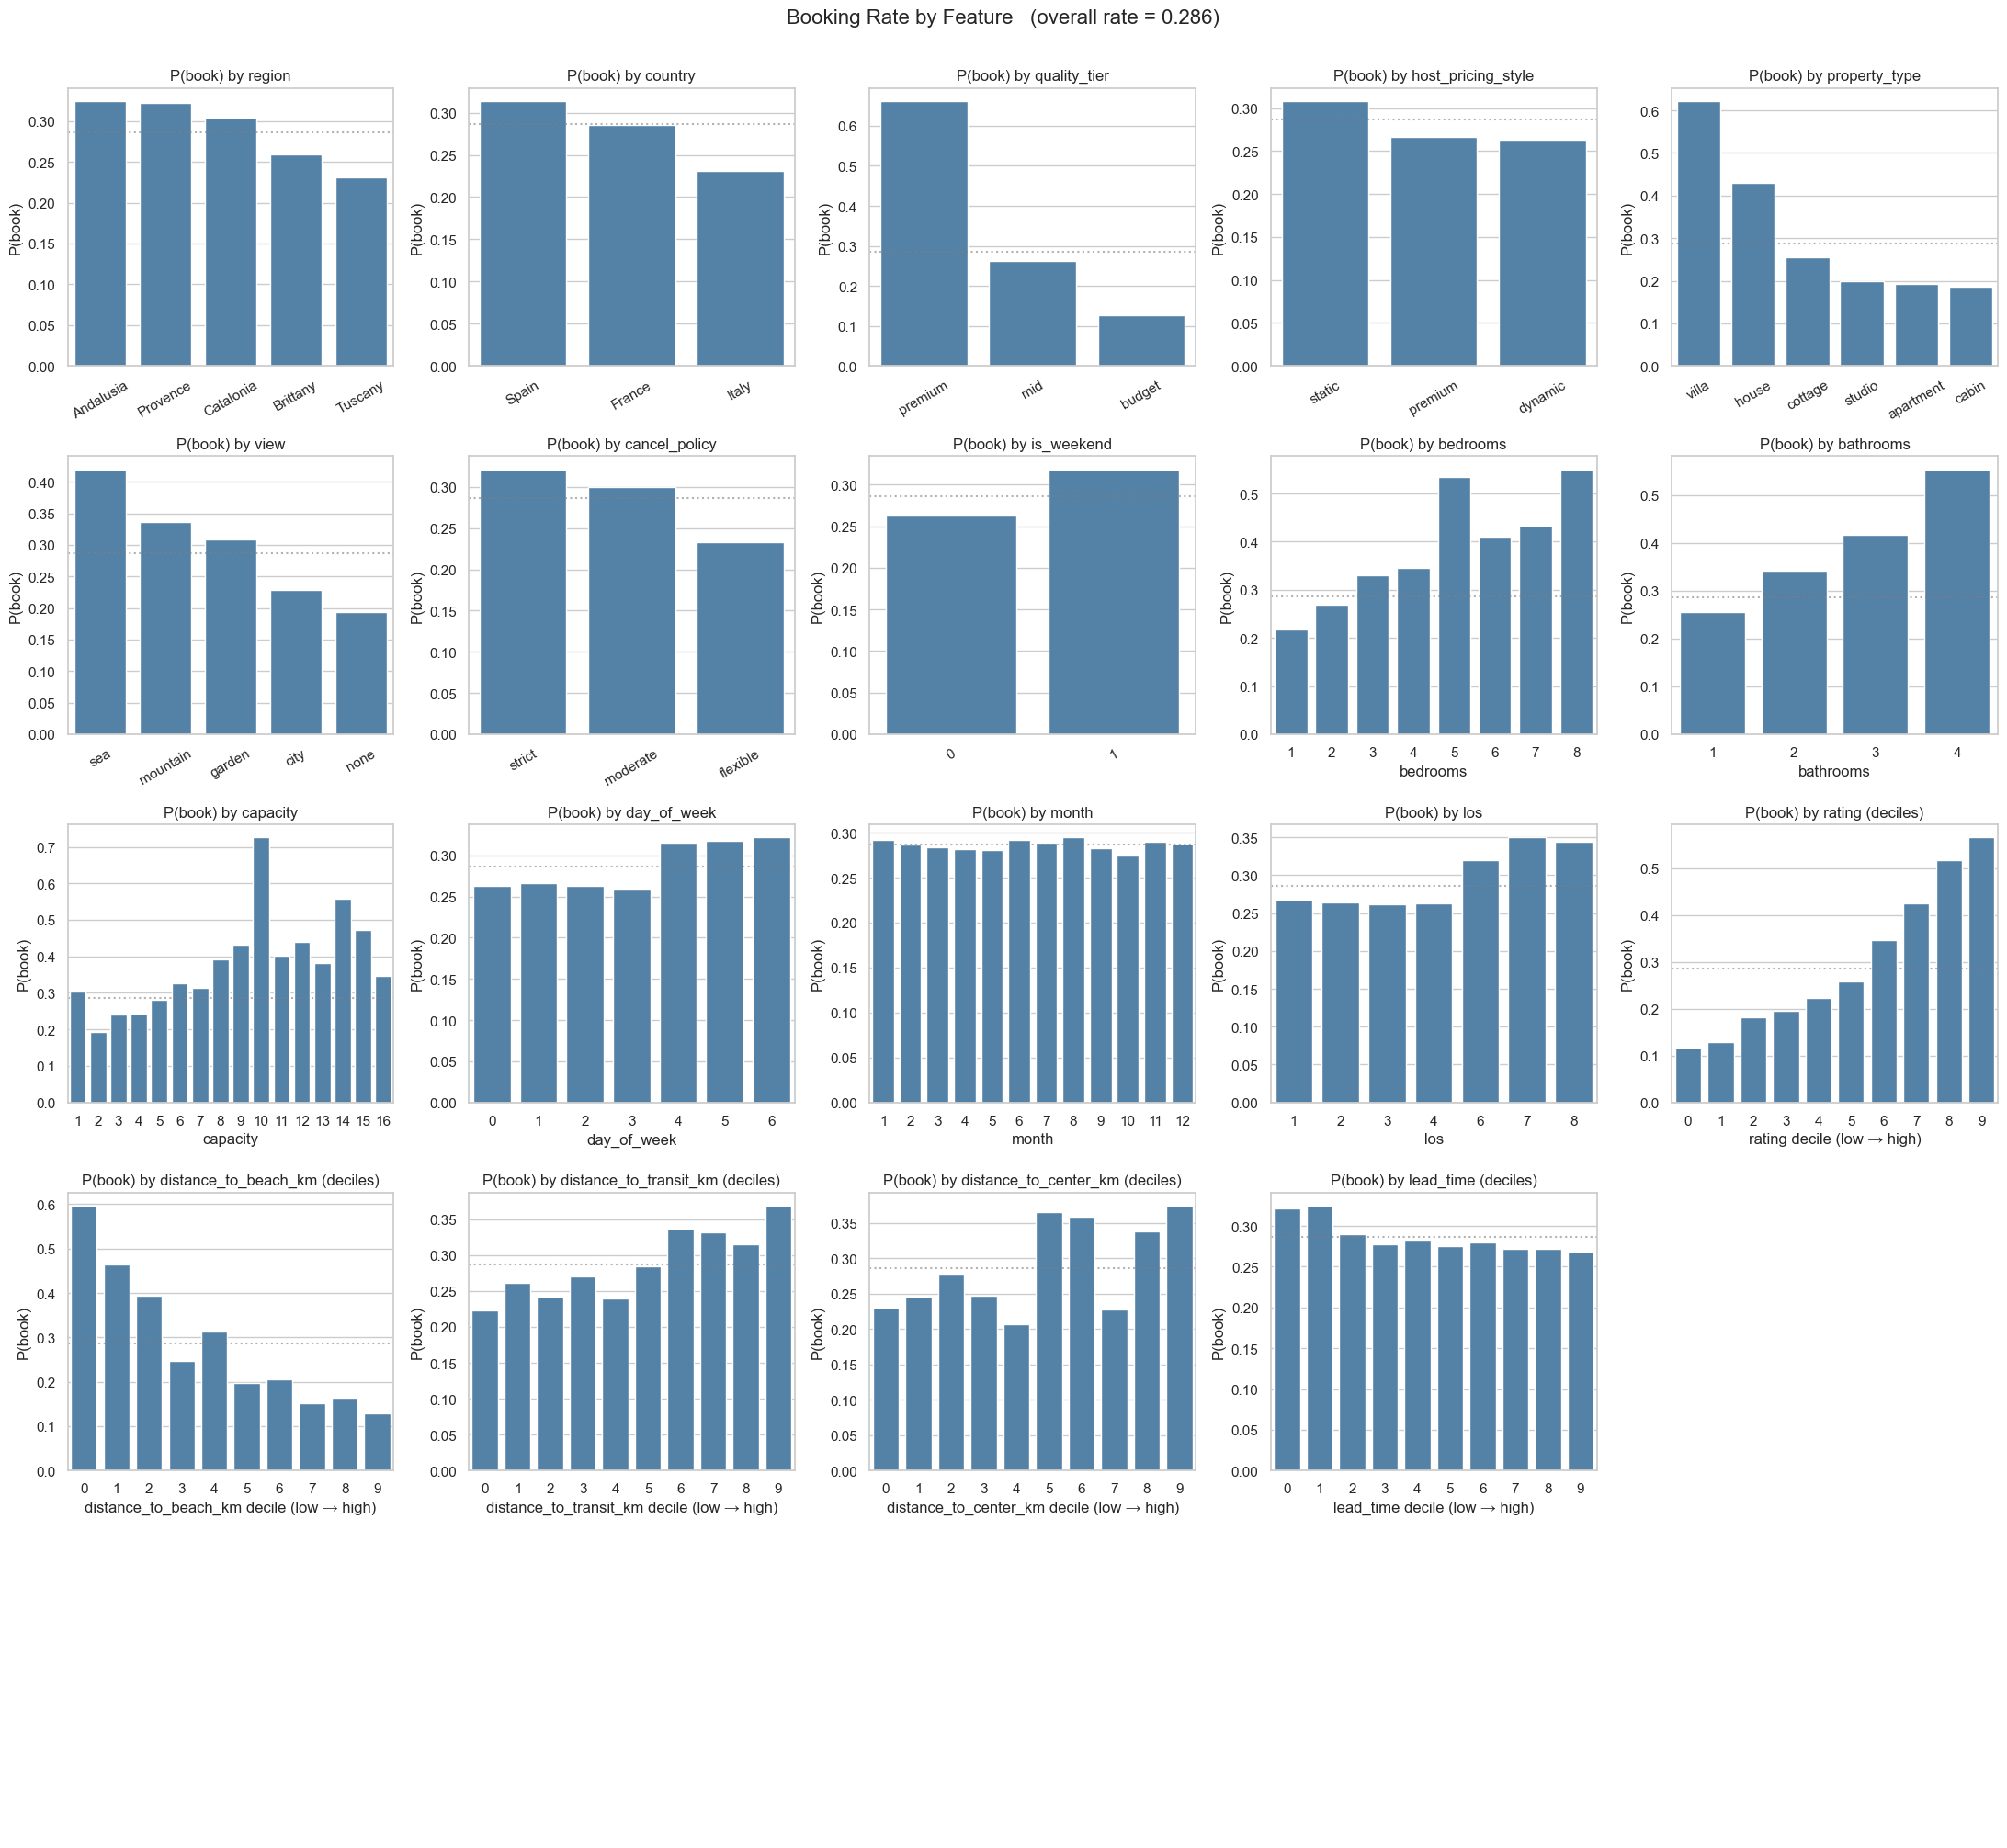

In [91]:
# Booking rate by feature — 5×5 grid of mean P(book) per category / per bin.
# Dotted grey line = overall booking rate. Quick read of which features carry signal.

# Property attributes
CAT_FEATURES = [
    "region", "country", "quality_tier", "host_pricing_style",
    "property_type", "view", "cancel_policy",
]
ORD_FEATURES = ["bedrooms", "bathrooms", "capacity"]
NUM_FEATURES = [
    "rating",
    "distance_to_beach_km", "distance_to_transit_km", "distance_to_center_km",
]

# Event / calendar context
CONTEXT_CAT_FEATURES = ["is_weekend"]
CONTEXT_ORD_FEATURES = ["day_of_week", "month", "los"]
CONTEXT_NUM_FEATURES = ["lead_time"]

overall_rate = train_df["booking_bool"].mean()

fig, axes = plt.subplots(5, 5, figsize=(22, 20))
axes = axes.flatten()
idx = 0

# Categorical: mean P(book) per category, sorted by rate
for col in CAT_FEATURES + CONTEXT_CAT_FEATURES:
    ax = axes[idx]
    grouped = train_df.groupby(col)["booking_bool"].mean().sort_values(ascending=False)
    sns.barplot(x=grouped.index, y=grouped.values, ax=ax, color="steelblue")
    ax.set_title(f"P(book) by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("P(book)")
    ax.axhline(overall_rate, color="grey", linestyle=":", alpha=0.6)
    ax.tick_params(axis="x", rotation=30)
    idx += 1

# Ordinal integer: mean P(book) per integer value (preserve natural order)
for col in ORD_FEATURES + CONTEXT_ORD_FEATURES:
    ax = axes[idx]
    grouped = train_df.groupby(col)["booking_bool"].mean()
    sns.barplot(x=grouped.index, y=grouped.values, ax=ax, color="steelblue")
    ax.set_title(f"P(book) by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("P(book)")
    ax.axhline(overall_rate, color="grey", linestyle=":", alpha=0.6)
    idx += 1

# Continuous numeric: bin into deciles, mean P(book) per decile (low → high)
for col in NUM_FEATURES + CONTEXT_NUM_FEATURES:
    ax = axes[idx]
    binned = pd.qcut(train_df[col], q=10, duplicates="drop")
    grouped = train_df.groupby(binned, observed=True)["booking_bool"].mean()
    sns.barplot(x=range(len(grouped)), y=grouped.values, ax=ax, color="steelblue")
    ax.set_title(f"P(book) by {col} (deciles)")
    ax.set_xlabel(f"{col} decile (low → high)")
    ax.set_ylabel("P(book)")
    ax.axhline(overall_rate, color="grey", linestyle=":", alpha=0.6)
    idx += 1

# Hide unused panels
for j in range(idx, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"Booking Rate by Feature   (overall rate = {overall_rate:.3f})",
    fontsize=16, y=1.005,
)
plt.tight_layout()
plt.show()


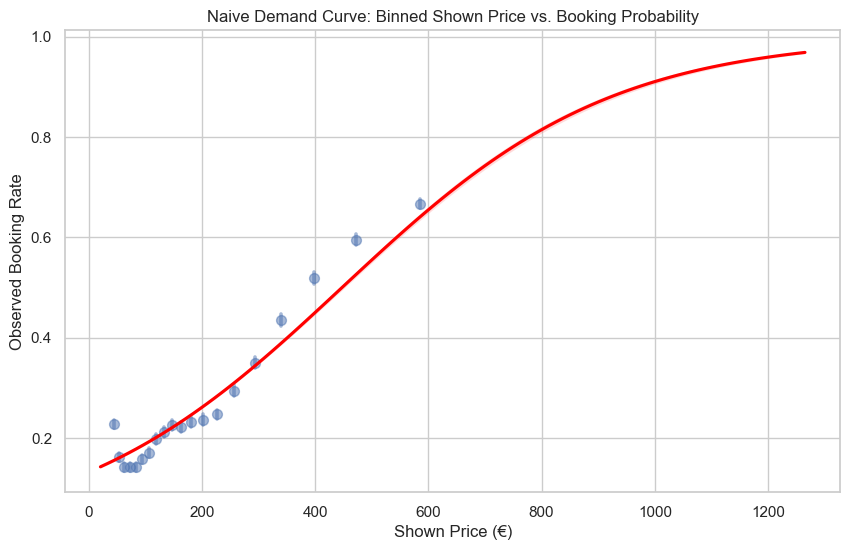

In [92]:
plt.figure(figsize=(10, 6))

# Binned regression plot (Deciles)
# This approximates the demand curve that Phase 4 must recover
sns.regplot(
    data=train_df, 
    x="shown_price", 
    y="booking_bool", 
    x_bins=20,  # Group prices into 20 bins
    logistic=True,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Naive Demand Curve: Binned Shown Price vs. Booking Probability")
plt.xlabel("Shown Price (€)")
plt.ylabel("Observed Booking Rate")
plt.show()

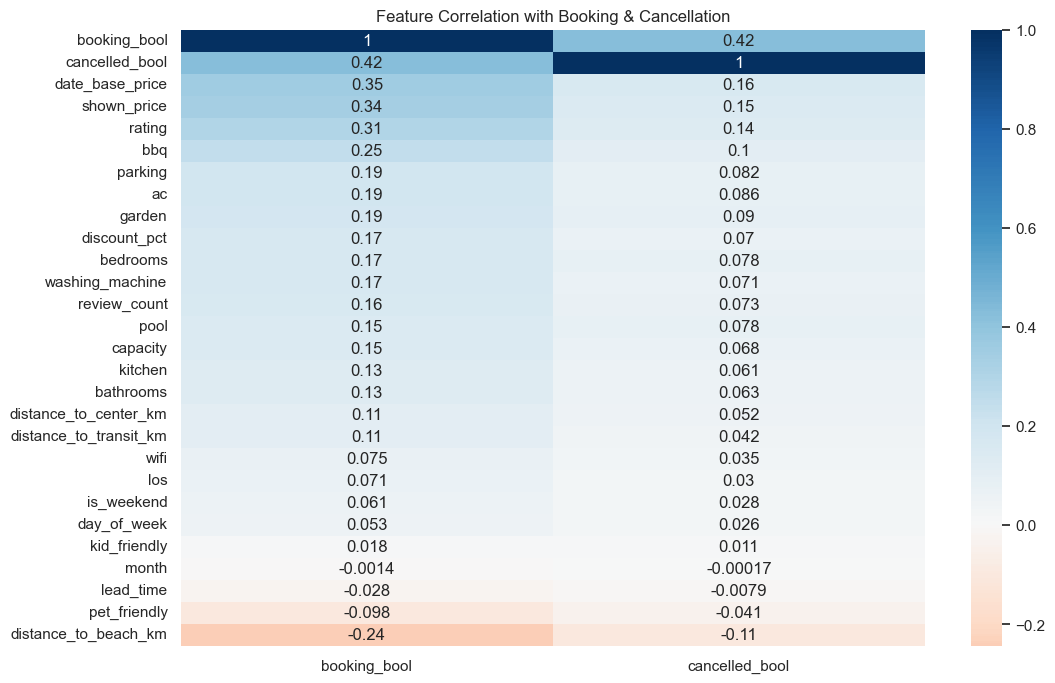

In [93]:
# Correlation Heatmap focused on Outcomes
plt.figure(figsize=(12, 8))
corr_matrix = train_df.select_dtypes(include=[np.number]).corr()

# Pull out the top correlations for our target
target_corr = corr_matrix[['booking_bool', 'cancelled_bool']].sort_values(by='booking_bool', ascending=False)

sns.heatmap(target_corr, annot=True, cmap="RdBu", center=0)
plt.title("Feature Correlation with Booking & Cancellation")
plt.show()

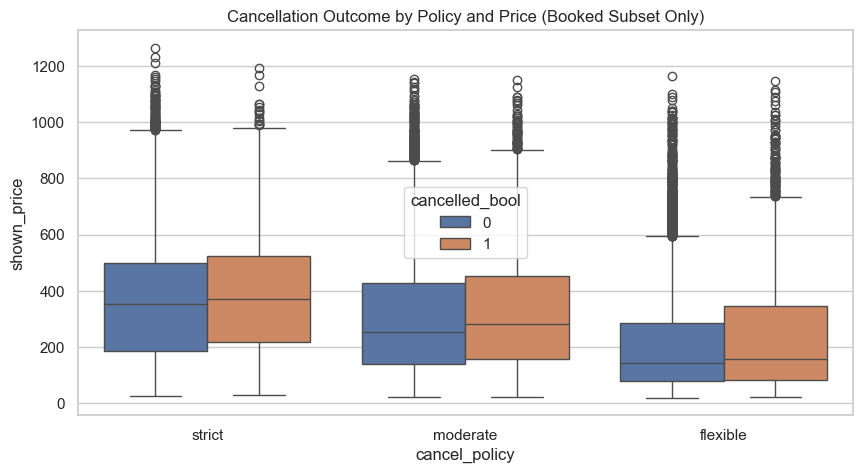

In [94]:
booked_df = train_df[train_df['booking_bool'] == 1]

plt.figure(figsize=(10, 5))
sns.boxplot(data=booked_df, x='cancel_policy', y='shown_price', hue='cancelled_bool')
plt.title("Cancellation Outcome by Policy and Price (Booked Subset Only)")
plt.show()

### Takeaways


1. Training data  shape : 145800 *37
2. No missingness. 
3. Booking rate: 28.6% Conditional cancel rate: 23.6%
4. Strong seasonality seen in prices and booking rate. Booking rate and shown_price both peak in summer and trough in winter, moving together.
Month and day of week matter.
5. A naive demand curve shows that prices and booking are positively correlated. This could be due to confounders. Naive elasticity gives wrong sign - causal estimation needed. - dml?
6. Visualisations of booking rate with features reveals that booking is more likely in Spain Anadalusia, remium properties, for villas, with a sea view, with lesser distance to the sea, for longer stays, bigger houses with more bathrooms. Correlation of booking wit distance_to_transit_km and distance_to_center_km  is quite weak 0.11.

## New Feature creation

1. one hot code the categorical variables.